In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils import logger, MyLogger
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

os.chdir(config.paths.roots.project)

torch.cuda.empty_cache()
# MyLogger.init_loggers()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 2472 samples
INFO     | setup | Validation Dataset  : 1354 samples


In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

In [6]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])


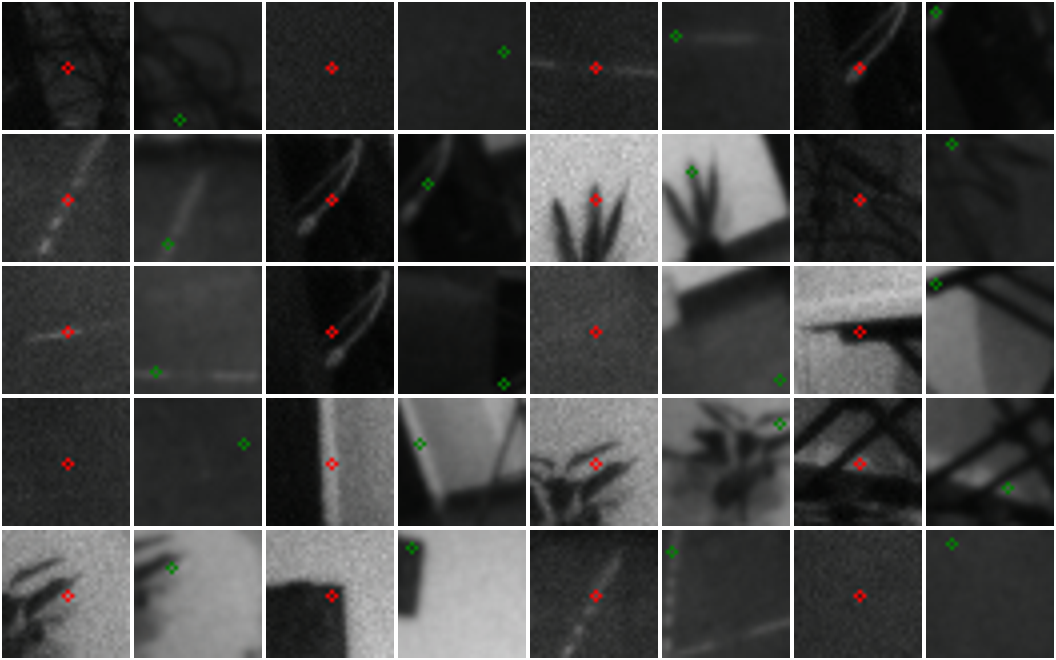

In [7]:
from utils import show_batch

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    limit_count=20, 
    n_columns=4,
)

In [8]:
for index, batch in enumerate(dl):
    print(f'-- Batch Index {index} -----')
    reference_patches = batch.reference_patches
    target_patches = batch.target_patches
    print(reference_patches.shape, target_patches.shape) 

    patch_level_reference_coords = batch.patch_level_reference_coords
    patch_level_target_coords = batch.patch_level_target_coords
    print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


-- Batch Index 0 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])
-- Batch Index 1 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])
-- Batch Index 2 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])
-- Batch Index 3 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])
-- Batch Index 4 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size([1024, 2])
-- Batch Index 5 -----
torch.Size([1023, 3, 32, 32]) torch.Size([1023, 3, 32, 32])
torch.Size([1023, 2]) torch.Size([1023, 2])
-- Batch Index 6 -----
torch.Size([951, 3, 32, 32]) torch.Size([951, 3, 32, 32])
torch.Size([951, 2]) torch.Size([951, 2])
-- Batch Index 7 -----
torch.Size([1024, 3, 32, 32]) torch.Size([1024, 3, 32, 32])
torch.Size([1024, 2]) torch.Size

KeyboardInterrupt: 

In [ ]:
dm.teardown()

# Check Model

In [ ]:
from src import MatcherModel, count_params
model = MatcherModel()

In [ ]:
# count_params(model.feature_extractor) # + count_params(model.mapper)
count_params(model.mapper)

In [ ]:
model.feature_extractor(reference_patches).shape

In [ ]:
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

target_coords_pred = model(reference_patches, target_patches, patch_level_reference_coords)

print(f'target_coords_pred shape : {target_coords_pred.shape}')

In [ ]:
loss = F.mse_loss(
    target_coords_pred.float() / 31.0,
    patch_level_target_coords.float() / 31.0,    
)

loss